<a href="https://colab.research.google.com/github/Gaveesha723/Adaptive-Noise-Cancelling-by-FIR-Filter/blob/main/Adp_FIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import soundfile as sf

In [13]:
class adp_fir_filter:
    def __init__(self,clean_path,noise_path,noisy_path,n_taps,mu):
      self.clean_path = clean_path
      self.noise_path = noise_path
      self.noisy_path = noisy_path
      self.n_taps = n_taps
      self.mu = mu

    def fir_filter(self):
      noisy, sr = librosa.load(self.noisy_path, sr=None)
      noise, sr = librosa.load(self.noise_path, sr=None)

      n_samples= min(len(noisy),len(noise))

      w=np.zeros(self.n_taps)                                # Weights = zeros
      e=np.zeros(n_samples)                             # error signal = zeros
      y=np.zeros(n_samples)                             # Reconstructed Noise signal = zeros

      for n in range(self.n_taps, n_samples):
        x_vector = noise[n:n-self.n_taps:-1]
        x_vector_t = np.transpose(x_vector)

        y[n]=np.dot(w,x_vector)
        e[n]=noisy[n]-y[n]

        w = w + ((self.mu/((x_vector_t*x_vector)+0.01)) * e[n] * x_vector)      # Normalized LMS
        # w = w + (mu * e[n] * x_vector)                                        # LMS

      return e,y,sr

    def plot_comparison(self,noisy,clean,reconstructd_clean,noise,reconstructed_noise,sr):

      noisy, sr= librosa.load(noisy, sr=None)
      clean, sr= librosa.load(clean, sr=None)
      reconstructd_clean, sr= librosa.load(reconstructd_clean, sr=None)
      noise, sr= librosa.load(noise, sr=None)
      reconstructed_noise, sr= librosa.load(reconstructed_noise, sr=None)

      duration = len(noisy)/sr
      time = np.arange(0,duration,1/sr)

      plt.figure(figsize=(20, 15))

      # Noisy plot
      plt.subplot(5, 1, 1)
      plt.plot(time, noisy, color = 'green', alpha= 0.7)
      plt.title('Noisy Audio')
      plt.xlabel('Time (s)')
      plt.ylabel('Amplitude')

      # Clean plot
      plt.subplot(5, 1, 2)
      plt.plot( time, clean, color = 'blue', alpha= 0.7)
      plt.title('Clean Audio')
      plt.xlabel('Time (s)')
      plt.ylabel('Amplitude')

      # Reconstructed audio signal plot
      plt.subplot(5, 1, 3)
      plt.plot( time, reconstructd_clean, color = 'purple', alpha= 0.7)
      plt.title('Reconstructed Clean Audio')
      plt.xlabel('Time (s)')
      plt.ylabel('Amplitude')

      # Noise plot
      plt.subplot(5, 1, 4)
      plt.plot( time, noise, color = 'red', alpha= 0.7)
      plt.title('Noise Audio')
      plt.xlabel('Time (s)')
      plt.ylabel('Amplitude')

      # Reconstructed noise plot
      plt.subplot(5,1,5)
      plt.plot( time, reconstructed_noise, color = 'purple', alpha= 0.7)
      plt.title('Reconstructed Noise Audio')
      plt.xlabel('Time (s)')
      plt.ylabel('Amplitude')



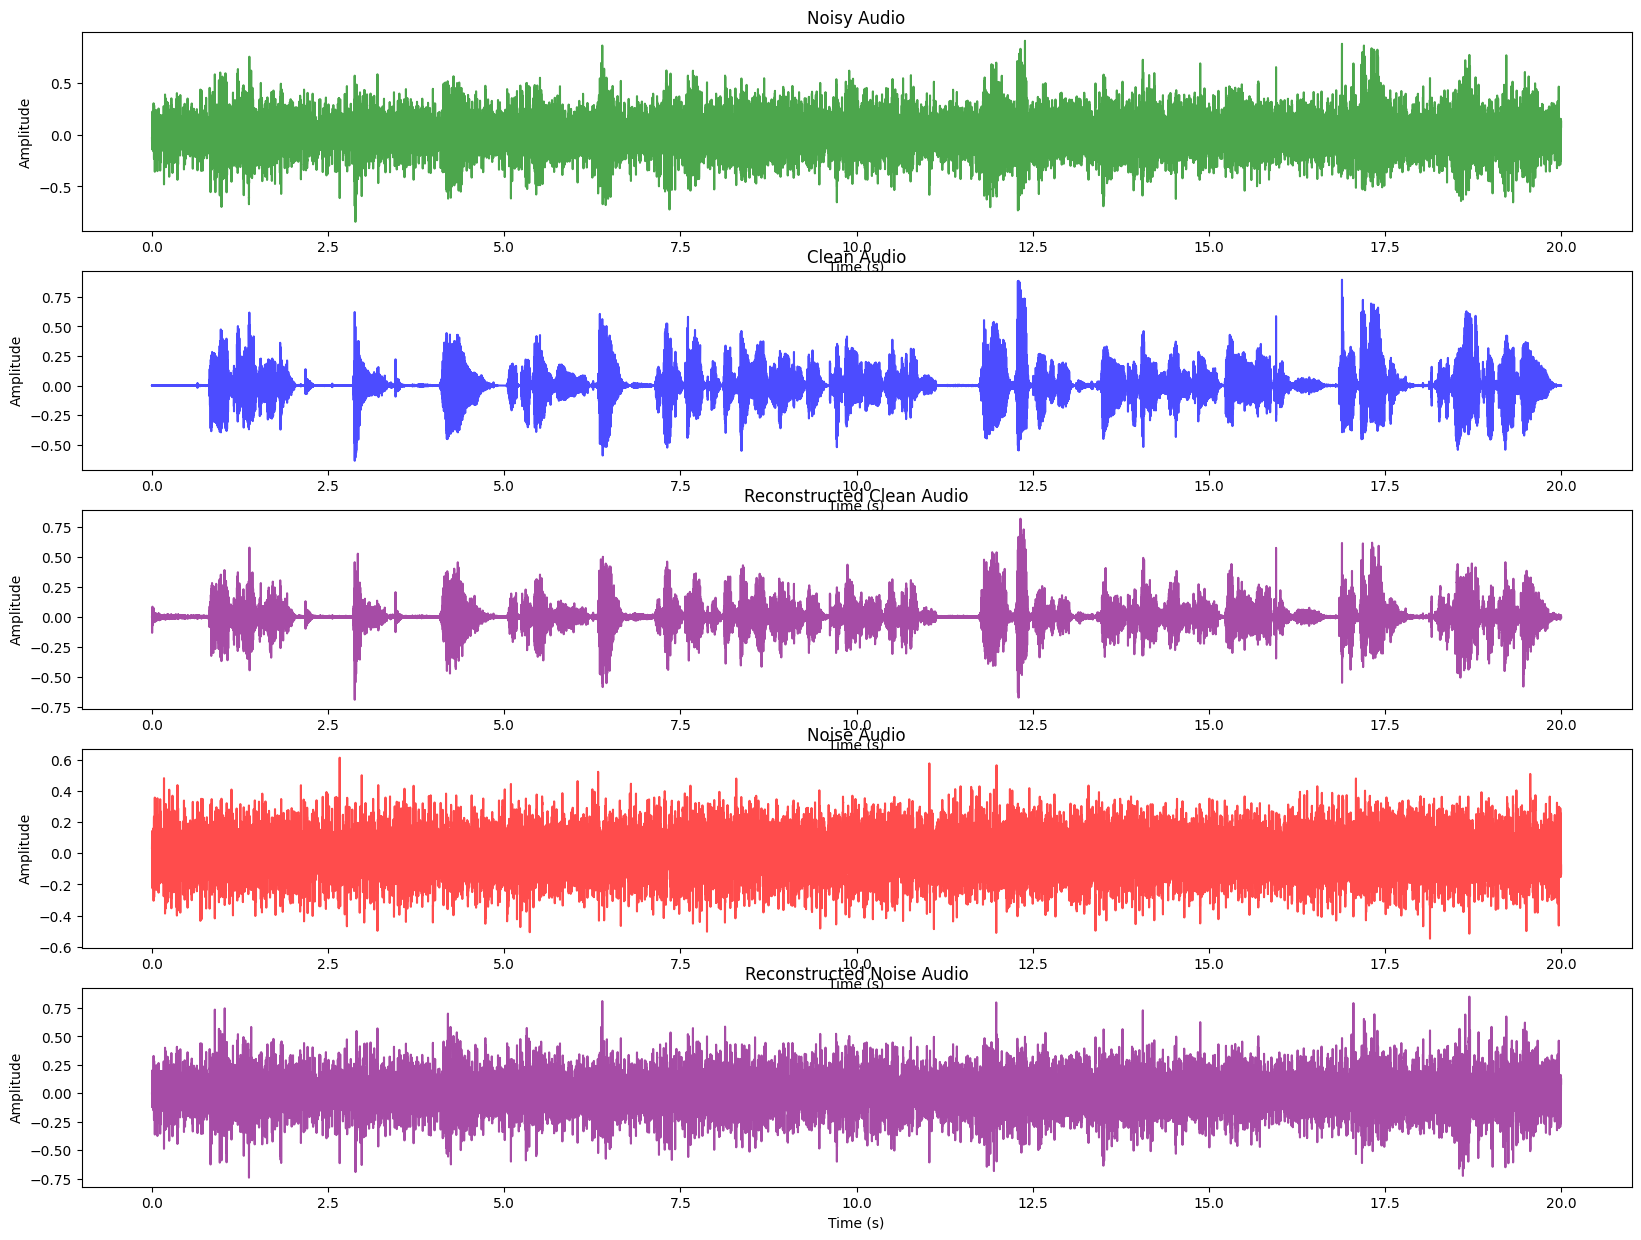

In [16]:
import librosa

# Load the files
clean = '/content/drive/MyDrive/Adaptive FIR Filter/my_project_data/clean_0.wav'
noisy= '/content/drive/MyDrive/Adaptive FIR Filter/my_project_data/noisy_0.wav'
noise_ref = '/content/drive/MyDrive/Adaptive FIR Filter/my_project_data/true_noise_0.wav'

filter_1= adp_fir_filter(clean,noise_ref,noisy,32,0.01)
denoised_signal,reconstructed_noise_signal,sr= filter_1.fir_filter()

# Writing output files
sf.write('/content/drive/MyDrive/Adaptive FIR Filter/my_project_output/denoised_output.wav', denoised_signal, sr)
sf.write('/content/drive/MyDrive/Adaptive FIR Filter/my_project_output/reconstructed_noise.wav', reconstructed_noise_signal, sr)

# Comparing
denoised_signal='/content/drive/MyDrive/Adaptive FIR Filter/my_project_output/denoised_output.wav'
reconstructed_noise_signal = '/content/drive/MyDrive/Adaptive FIR Filter/my_project_output/reconstructed_noise.wav'
filter_1.plot_comparison(noisy,clean,denoised_signal,noise_ref,reconstructed_noise_signal,sr)